# Quality Control

## Load count matrix

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy.stats import median_abs_deviation
import rpy2
%load_ext rpy2.ipython
import anndata2ri
from rpy2.robjects import r
from rpy2.robjects.conversion import localconverter
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import anndata as ad

rcb.logger.setLevel(logging.ERROR)

sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=False,
)

In [2]:
%%R
library(ensembldb)
library(EnsDb.Hsapiens.v86)
library(SoupX)
library(Seurat)
library(scater)
library(scDblFinder)
library(BiocParallel)
library(SingleCellExperiment)


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

In [3]:
%%R -o sce

# Read the empty-drop filtered count matrix RDS file for each sample, combine into a single SingleCellExperiment (SCE) object,
# add gene symbols and full names for each gene Ensembl ID, and output SCE object to Python

# Load Hair_graft_4 count matrix
rds_path1 <- "../../raw_data_processing/results/alevin/mtx_conversions/Hair_graft_4/Hair_graft_4_emptydrops_filter_matrix.sce.rds"
sce_s4_filtered <- readRDS(rds_path1)
# Append sample name to each cell name
colnames(sce_s4_filtered) <- paste0(colnames(sce_s4_filtered), "_", colData(sce_s4_filtered)$sample)

# Load Hair_graft_5 count matrix
rds_path2 <- "../../raw_data_processing/results/alevin/mtx_conversions/Hair_graft_5/Hair_graft_5_emptydrops_filter_matrix.sce.rds"
sce_s5_filtered <- readRDS(rds_path2)
# Append sample name to each cell name
colnames(sce_s5_filtered) <- paste0(colnames(sce_s5_filtered), "_", colData(sce_s5_filtered)$sample)

# Combine the SCE objects for the two samples
sce <- cbind(sce_s4_filtered, sce_s5_filtered)

# Extract Ensembl gene IDs
ensembl_ids <- rownames(sce)

# Convert Ensembl IDs to gene symbols
gene_symbols <- mapIds(EnsDb.Hsapiens.v86, 
                       keys = ensembl_ids, 
                       column = "SYMBOL", 
                       keytype = "GENEID", 
                       multiVals = "first")

# Convert Ensembl IDs to full gene names
gene_names <- mapIds(EnsDb.Hsapiens.v86, 
                     keys = ensembl_ids, 
                     column = "GENENAME", 
                     keytype = "GENEID", 
                     multiVals = "first")

# Add gene symbols and gene names to rowData
rowData(sce)$gene_symbol <- gene_symbols
rowData(sce)$gene_name <- gene_names

# Check the first few mappings
head(rowData(sce))



DataFrame with 6 rows and 3 columns
                  gene_versions gene_symbol   gene_name
                    <character> <character> <character>
ENSG00000001461 ENSG00000001461      NIPAL3      NIPAL3
ENSG00000010072 ENSG00000010072       SPRTN       SPRTN
ENSG00000008118 ENSG00000008118      CAMK1G      CAMK1G
ENSG00000009780 ENSG00000009780      FAM76A      FAM76A
ENSG00000048707 ENSG00000048707      VPS13D      VPS13D
ENSG00000041988 ENSG00000041988       THAP3       THAP3


In [4]:
print(sce)

class: SingleCellExperiment 
dim: 236796 5306 
metadata(0):
assays(1): X
rownames(236796): ENSG00000001461 ENSG00000010072 ... ENSG00000310554-A
  ENSG00000310555-A
rowData names(3): gene_versions gene_symbol gene_name
colnames(5306): AGATTGCTCCCTCAGT_Hair_graft_4
  CTCGAAACATTCGACA_Hair_graft_4 ... CGATTGATCTGTGCAA_Hair_graft_5
  ACCTTTAGTTTAGGAA_Hair_graft_5
colData names(1): sample
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):



In [5]:
# Convert the SingleCellExperiment object to AnnData object
with localconverter(anndata2ri.converter):
    adata = r('as(sce, "SingleCellExperiment")')

print(adata)

AnnData object with n_obs × n_vars = 5306 × 236796
    obs: 'sample'
    var: 'gene_versions', 'gene_symbol', 'gene_name'


In [6]:
gene_df = pd.DataFrame(adata.var)
gene_df

,gene_versions,gene_symbol,gene_name
ENSG00000001461,ENSG00000001461,NIPAL3,NIPAL3
ENSG00000010072,ENSG00000010072,SPRTN,SPRTN
ENSG00000008118,ENSG00000008118,CAMK1G,CAMK1G
ENSG00000009780,ENSG00000009780,FAM76A,FAM76A
ENSG00000048707,ENSG00000048707,VPS13D,VPS13D
...,...,...,...
ENSG00000310550-A,ENSG00000310550-A,None,None
ENSG00000310552-A,ENSG00000310552-A,None,None
ENSG00000310553-A,ENSG00000310553-A,None,None
ENSG00000310554-A,ENSG00000310554-A,None,None


In [7]:
# Use only genes with valid gene symbols (exclude unstable and alternative gene counts)
adata.var['na_genes'] = adata.var['gene_symbol'].isna()
adata = adata[:, ~adata.var['na_genes']].copy()
adata.var_names = adata.var['gene_symbol'].values.astype(str)
adata.var_names_make_unique()
adata.var.drop('na_genes', axis=1, inplace=True)
adata

/opt/conda/envs/preprocessing/lib/python3.10/site-packages/anndata/utils.py:268: UserWarning: Suffix used (-[0-9]+) to deduplicate index values may make index values difficult to interpret. There values with a similar suffixes in the index. Consider using a different delimiter by passing `join={delimiter}`Example key collisions generated by the make_index_unique algorithm: ['SNORD116-1', 'SNORD116-2', 'SNORD116-3', 'SNORD116-4', 'SNORD116-5']
  warnings.warn(


AnnData object with n_obs × n_vars = 5306 × 56134
    obs: 'sample'
    var: 'gene_versions', 'gene_symbol', 'gene_name'

## Filter low quality cells

In [8]:
# mitochondrial genes
adata.var['mt'] = adata.var['gene_symbol'].str.startswith("MT-", na=False)
# ribosomal genes
adata.var['ribo'] = adata.var['gene_symbol'].str.startswith(("RPS", "RPL"), na=False)
# hemoglobin genes
adata.var['hb'] = adata.var['gene_symbol'].str.contains("^HB[^(P)]", na=False)

In [9]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
adata

AnnData object with n_obs × n_vars = 5306 × 56134
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_versions', 'gene_symbol', 'gene_name', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

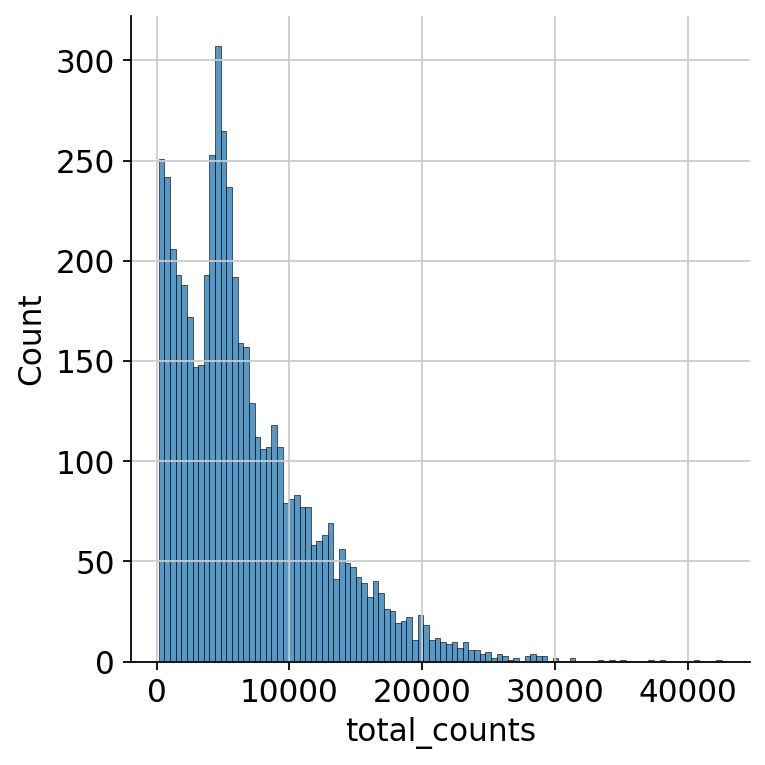

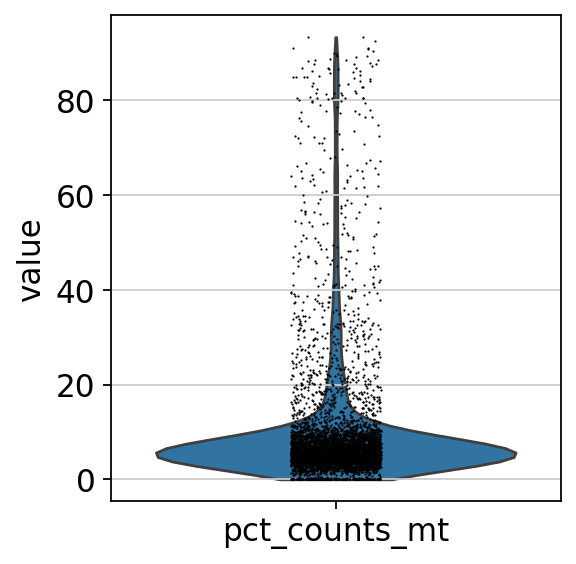

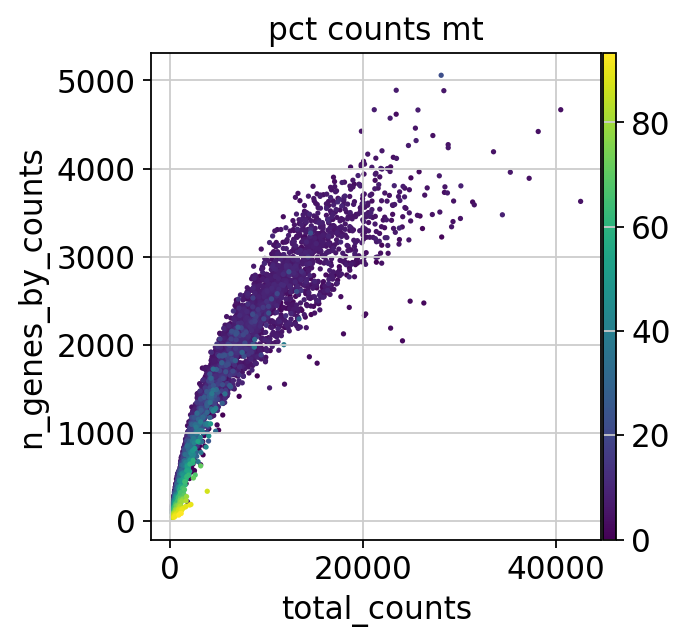

In [10]:
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
# sc.pl.violin(adata, 'total_counts')
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [11]:
# Outlier thresholding based on median absolute deviations (MADs)
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

In [12]:
# apply this function to the log1p_total_counts, log1p_n_genes_by_counts and
# pct_counts_in_top_20_genes QC covariates each with a threshold of 5 MADs
adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5)
    | is_outlier(adata, "log1p_n_genes_by_counts", 5)
    | is_outlier(adata, "pct_counts_in_top_20_genes", 5)
)
adata.obs.outlier.value_counts()

outlier
False    4680
True      626
Name: count, dtype: int64

In [13]:
# Mark cells with % mitochondrial counts > 3 MADs
# or mitochondrial counts > 8%
adata.obs["mt_outlier"] = is_outlier(adata, "pct_counts_mt", 3) | (
    adata.obs["pct_counts_mt"] > 8
)
adata.obs.mt_outlier.value_counts()

mt_outlier
False    3724
True     1582
Name: count, dtype: int64

In [14]:
# filter our AnnData object based on these two additional columns
print(f"Total number of cells: {adata.n_obs}")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

Total number of cells: 5306
Number of cells after filtering of low quality cells: 3564


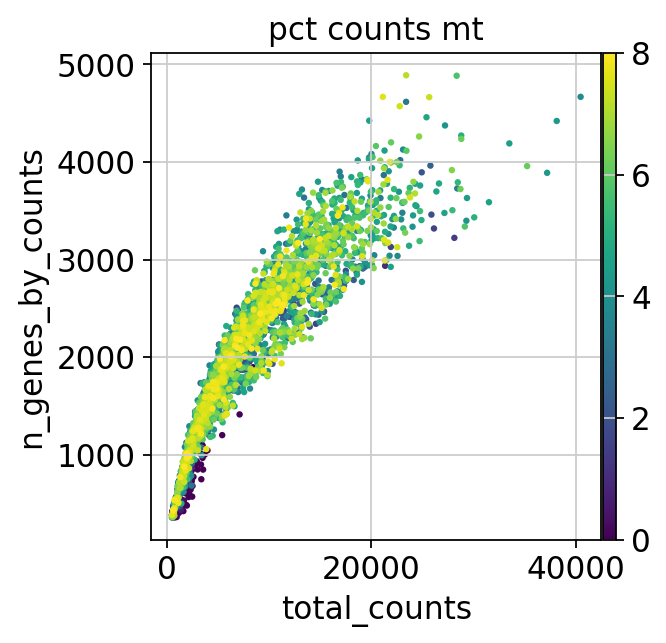

In [15]:
p1 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

## Correction of ambient RNA

In [16]:
# generate a copy of our AnnData object, normalize and log1p transform it
adata_pp = adata.copy()
sc.pp.normalize_per_cell(adata_pp)
sc.pp.log1p(adata_pp)

In [17]:
sc.pp.pca(adata_pp) # compute principle components
sc.pp.neighbors(adata_pp) # generate KNN graph
sc.tl.leiden(adata_pp, key_added="soupx_groups") # run leiden clustering

# Preprocess variables for SoupX
soupx_groups = adata_pp.obs["soupx_groups"]

/opt/conda/envs/preprocessing/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_24962/2847450567.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_pp, key_added="soupx_groups") # run leiden clustering


In [18]:
# delete AnnData object copy
del adata_pp

In [19]:
# save the cell IDs, gene IDs, and the counts of the filtered count matrix
cells = adata.obs_names
genes = adata.var_names
data = adata.X.T

In [20]:
%%R -o raw_sce
# Read the combined, raw count matrix RDS file and output SingleCellExperiment object to Python
rds_path <- "../raw_data_processing/results/alevin/mtx_conversions/combined_raw_matrix.sce.rds"
raw_sce <- readRDS(rds_path)


Error in gzfile(file, "rb") : cannot open the connection


RInterpreterError: Failed to parse and evaluate line '# Read the combined, raw count matrix RDS file and output SingleCellExperiment object to Python\nrds_path <- "../raw_data_processing/results/alevin/mtx_conversions/combined_raw_matrix.sce.rds"\nraw_sce <- readRDS(rds_path)\n'.
R error message: 'Error in gzfile(file, "rb") : cannot open the connection'

In [ ]:
# convert raw count matrix from SCE to AnnData and extract counts
with localconverter(anndata2ri.converter):
    adata_raw = r('as(raw_sce, "SingleCellExperiment")')

data_tod = adata_raw.X.T
del adata_raw

In [21]:
data_tod = adata.X.T

In [22]:
with (ro.default_converter + anndata2ri.converter).context():
  r_data = ro.conversion.get_conversion().py2rpy(data)
  r_data_tod = ro.conversion.get_conversion().py2rpy(data_tod)

In [23]:
%%R -i r_data -i r_data_tod -i genes -i cells -i soupx_groups -o r_out 

# specify row and column names of data
data <- r_data
data_tod <- r_data_tod
rownames(data) = genes
colnames(data) = cells
# ensure correct sparse format for table of counts and table of droplets
data <- as(data, "sparseMatrix")
data_tod <- as(data_tod, "sparseMatrix")

# Generate SoupChannel Object for SoupX 
sc = SoupChannel(data_tod, data, calcSoupProfile = FALSE)

# Add extra meta data to the SoupChannel object
soupProf = data.frame(row.names = rownames(data), est = rowSums(data)/sum(data), counts = rowSums(data))
sc = setSoupProfile(sc, soupProf)
# Set cluster information in SoupChannel
sc = setClusters(sc, soupx_groups)

# Estimate contamination fraction
sc  = autoEstCont(sc, doPlot=FALSE)
# Infer corrected table of counts and rount to integer
r_out = adjustCounts(sc, roundToInt = TRUE)

: 

In [ ]:
with (ro.default_converter + anndata2ri.converter).context():
  out = ro.conversion.get_conversion().rpy2py(r_out)

In [ ]:
# add a new layer to the AnnData object with the SoupX background RNA-corrected count matrix
# and replace the current count matrix with this corrected count matrix
adata.layers["counts"] = adata.X
adata.layers["soupX_counts"] = out.T
adata.X = adata.layers["soupX_counts"]

## Doublet Detection

In [ ]:
data_mat = adata.X.T

In [ ]:
with (ro.default_converter + anndata2ri.converter).context():
  r_data_mat = ro.conversion.get_conversion().py2rpy(data)

In [ ]:
%%R -i r_data_mat -o r_doublet_score -o r_doublet_class
# Use scDblFinder to detect doublets
set.seed(123)
sce = scDblFinder(
    SingleCellExperiment(
        list(counts=r_data_mat),
    ) 
)
r_doublet_score = sce$scDblFinder.score
r_doublet_class = sce$scDblFinder.class

In [ ]:
with (ro.default_converter + anndata2ri.converter).context():
  doublet_score = ro.conversion.get_conversion().rpy2py(r_doublet_score)
  doublet_class = ro.conversion.get_conversion().rpy2py(r_doublet_class)

In [ ]:
adata.obs["scDblFinder_score"] = doublet_score
adata.obs["scDblFinder_class"] = doublet_class
adata.obs.scDblFinder_class.value_counts()

scDblFinder_class
singlet    863
doublet     29
Name: count, dtype: int64

In [ ]:
# save the dataset to file
ad.settings.allow_write_nullable_strings = True
adata.write("quality_control.h5ad.gz", compression='gzip')